In [14]:
import pandas as pd 
import numpy as np
import anndata as ad
from scipy.sparse import coo_matrix, csr_matrix
import seaborn as sns
import scanpy as sc
import os
import glob
import re
import sys
from typing import List, Set
import gffutils 

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")


Imports successful!


In [12]:
def extract_unique_transcripts(juncs: pd.DataFrame) -> List[str]:
    """
    Extract unique transcripts from all transcript-related columns in junction DataFrame.
    Handles string lists, NA values, and ensures uniqueness.
    
    Args:
        juncs: DataFrame containing junction data with transcript columns
        
    Returns:
        List of unique transcript IDs
    """
    # Columns to extract transcripts from
    transcript_columns = [
        "perfect_match_5_prime", 
        "perfect_match_3_prime"
    ]
    
    # Set to store unique transcripts
    all_transcripts: Set[str] = set()
    
    # Process each column
    for column in transcript_columns:
        if column not in juncs.columns:
            print(f"Warning: Column '{column}' not found in DataFrame")
            continue
            
        # Process each row in the column
        for value in juncs[column]:
            # Skip NA/None values
            if pd.isna(value) or value == 'NA' or value is None:
                continue
                
            # Handle string lists (comma-separated values)
            if isinstance(value, str):
                # Skip empty strings
                if value.strip() == '':
                    continue
                    
                # Split by comma and add each transcript to the set
                for transcript in value.split(','):
                    transcript = transcript.strip()
                    if transcript and transcript != 'NA':
                        all_transcripts.add(transcript)
            
            # Handle actual Python lists
            elif isinstance(value, list):
                for transcript in value:
                    if transcript and not pd.isna(transcript) and transcript != 'NA':
                        all_transcripts.add(str(transcript))
    
    # Convert set to sorted list for consistent output
    return sorted(list(all_transcripts))

In [ ]:
# Output DIR 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025"
print(f"Output directory: {output_dir}", flush=True)

# Find the most recently created file in the directory ending in *.h5ad
h5ad_file = max(glob.glob("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/*.h5ad"), key=os.path.getctime)
print(f"Most recent file: {h5ad_file}", flush=True)

# Load the h5ad file
adata = ad.read_h5ad(h5ad_file)
print(f"Loaded h5ad file: {h5ad_file}", flush=True)

AnnData object with n_obs × n_vars = 88459 × 31827
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type_grouped', 'cell_type', 'broad_cell_type', 'cell_id_index', 'seqtech'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index'
    uns: 'neighbors', 'pca_explained_variance_ratio', 'seqtech_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'phi_init_100_waypoints'
    varm: 'psi_init_100_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix'
    obsp: 'connectivities', 'distances'

In [3]:
adata.var[adata.var["gene_name"] == "CSDE1"]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_id_index
13004,chr1_114718745_114719578_-,ATSE_6395,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,889208,15931,0.180076,2.0,1.5,1,13004
13005,chr1_114718745_114720538_-,ATSE_6395,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,9071,890,0.010060,2.0,1.5,1,13005
13006,chr1_114719742_114720538_-,ATSE_6395,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,705469,13288,0.150201,2.0,1.5,1,13006
13007,chr1_114727087_114730257_-,ATSE_6396,GT-AG,both,CSDE1,ENSG00000009307.17,4,1.0,0.0,9376,1274,0.014401,2.0,1.5,1,13007
13008,chr1_114727090_114730257_-,ATSE_6396,GT-AG,both,CSDE1,ENSG00000009307.17,4,1.0,0.0,296578,8753,0.098940,2.0,1.5,1,13008
13009,chr1_114727090_114732603_-,ATSE_6396,GT-AG,both,CSDE1,ENSG00000009307.17,4,1.0,0.0,4280,188,0.002125,2.0,0.0,1,13009
13010,chr1_114730648_114732603_-,ATSE_6396,GT-AG,both,CSDE1,ENSG00000009307.17,4,1.0,0.0,232975,7497,0.084743,2.0,1.5,1,13010
13011,chr1_114736855_114737470_-,ATSE_6397,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,17201,896,0.010128,2.0,1.5,1,13011
13012,chr1_114736855_114737962_-,ATSE_6397,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,182282,6353,0.071811,2.0,1.5,1,13012
13013,chr1_114737563_114737962_-,ATSE_6397,GT-AG,both,CSDE1,ENSG00000009307.17,3,1.0,0.0,17770,994,0.011236,2.0,1.5,1,13013


In [13]:
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-04-22_14-07-59.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"The number of ATSEs in this dataset is {len(atses['event_id'].unique())}", flush=True)

human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

The number of ATSEs in this dataset is 22164


In [6]:
atses[atses["gene_name"] == "CSDE1"]

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcript_types,annotation_status,perfect_match_5_prime,perfect_match_3_prime,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
19273,ATSE_6395,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.0101,0.0101,0.0127,898279,714540,GT-AG,GT,AG,1.0,0.0
19274,ATSE_6395,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.9873,0.9873,1.0000,714540,705469,GT-AG,GT,AG,1.0,0.0
19275,ATSE_6395,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,1.0000,1.0000,0.9899,889208,898279,GT-AG,GT,AG,1.0,0.0
19276,ATSE_6396,ENSG00000009307.17,CSDE1,protein_coding,4,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.9820,0.9820,1.0000,237255,232975,GT-AG,GT,AG,1.0,0.0
19277,ATSE_6396,ENSG00000009307.17,CSDE1,protein_coding,4,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.9694,0.9694,0.9858,305954,300858,GT-AG,GT,AG,1.0,0.0
19278,ATSE_6396,ENSG00000009307.17,CSDE1,protein_coding,4,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.0142,0.0142,0.0180,300858,237255,GT-AG,GT,AG,1.0,0.0
19279,ATSE_6396,ENSG00000009307.17,CSDE1,protein_coding,4,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...",ENST00000691403.1,...,0.0306,0.0306,1.0000,305954,9376,GT-AG,GT,AG,1.0,0.0
19280,ATSE_6397,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.9112,0.9112,0.9138,200052,199483,GT-AG,GT,AG,1.0,0.0
19281,ATSE_6397,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000689989.1,ENST00000689217.1,ENST000006...","ENST00000339438.10,ENST00000689989.1,ENST00000...",...,0.0862,0.0862,1.0000,199483,17201,GT-AG,GT,AG,1.0,0.0
19282,ATSE_6397,ENSG00000009307.17,CSDE1,protein_coding,3,complex,"protein_coding,protein_coding_CDS_not_defined,...",both,"ENST00000339438.10,ENST00000689989.1,ENST00000...","ENST00000689989.1,ENST00000689217.1,ENST000006...",...,0.0888,0.0888,1.0000,200052,17770,GT-AG,GT,AG,1.0,0.0


{'ENST00000261443.9': {'transcript_id': 'ENST00000261443.9', 'transcript_name': 'CSDE1-201', 'transcript_type': 'protein_coding', 'chromosome': 'chr1', 'exons': [(114717295, 114718216), (114718613, 114718745), (114719579, 114719742), (114720539, 114720717), (114723883, 114724002), (114725221, 114725333), (114726211, 114726386), (114726983, 114727090), (114730258, 114730422), (114730508, 114730648), (114732604, 114732816), (114733732, 114733857), (114733989, 114734117), (114734442, 114734523), (114736758, 114736855), (114737963, 114738072), (114739692, 114739890), (114757925, 114757974)], 'cds': [(114718172, 114718216), (114718613, 114718745), (114719579, 114719742), (114720539, 114720717), (114723883, 114724002), (114725221, 114725333), (114726211, 114726386), (114726983, 114727090), (114730258, 114730422), (114730508, 114730648), (114732604, 114732816), (114733732, 114733857), (114733989, 114734117), (114734442, 114734523), (114736758, 114736855), (114737963, 114738072), (114739692, 1

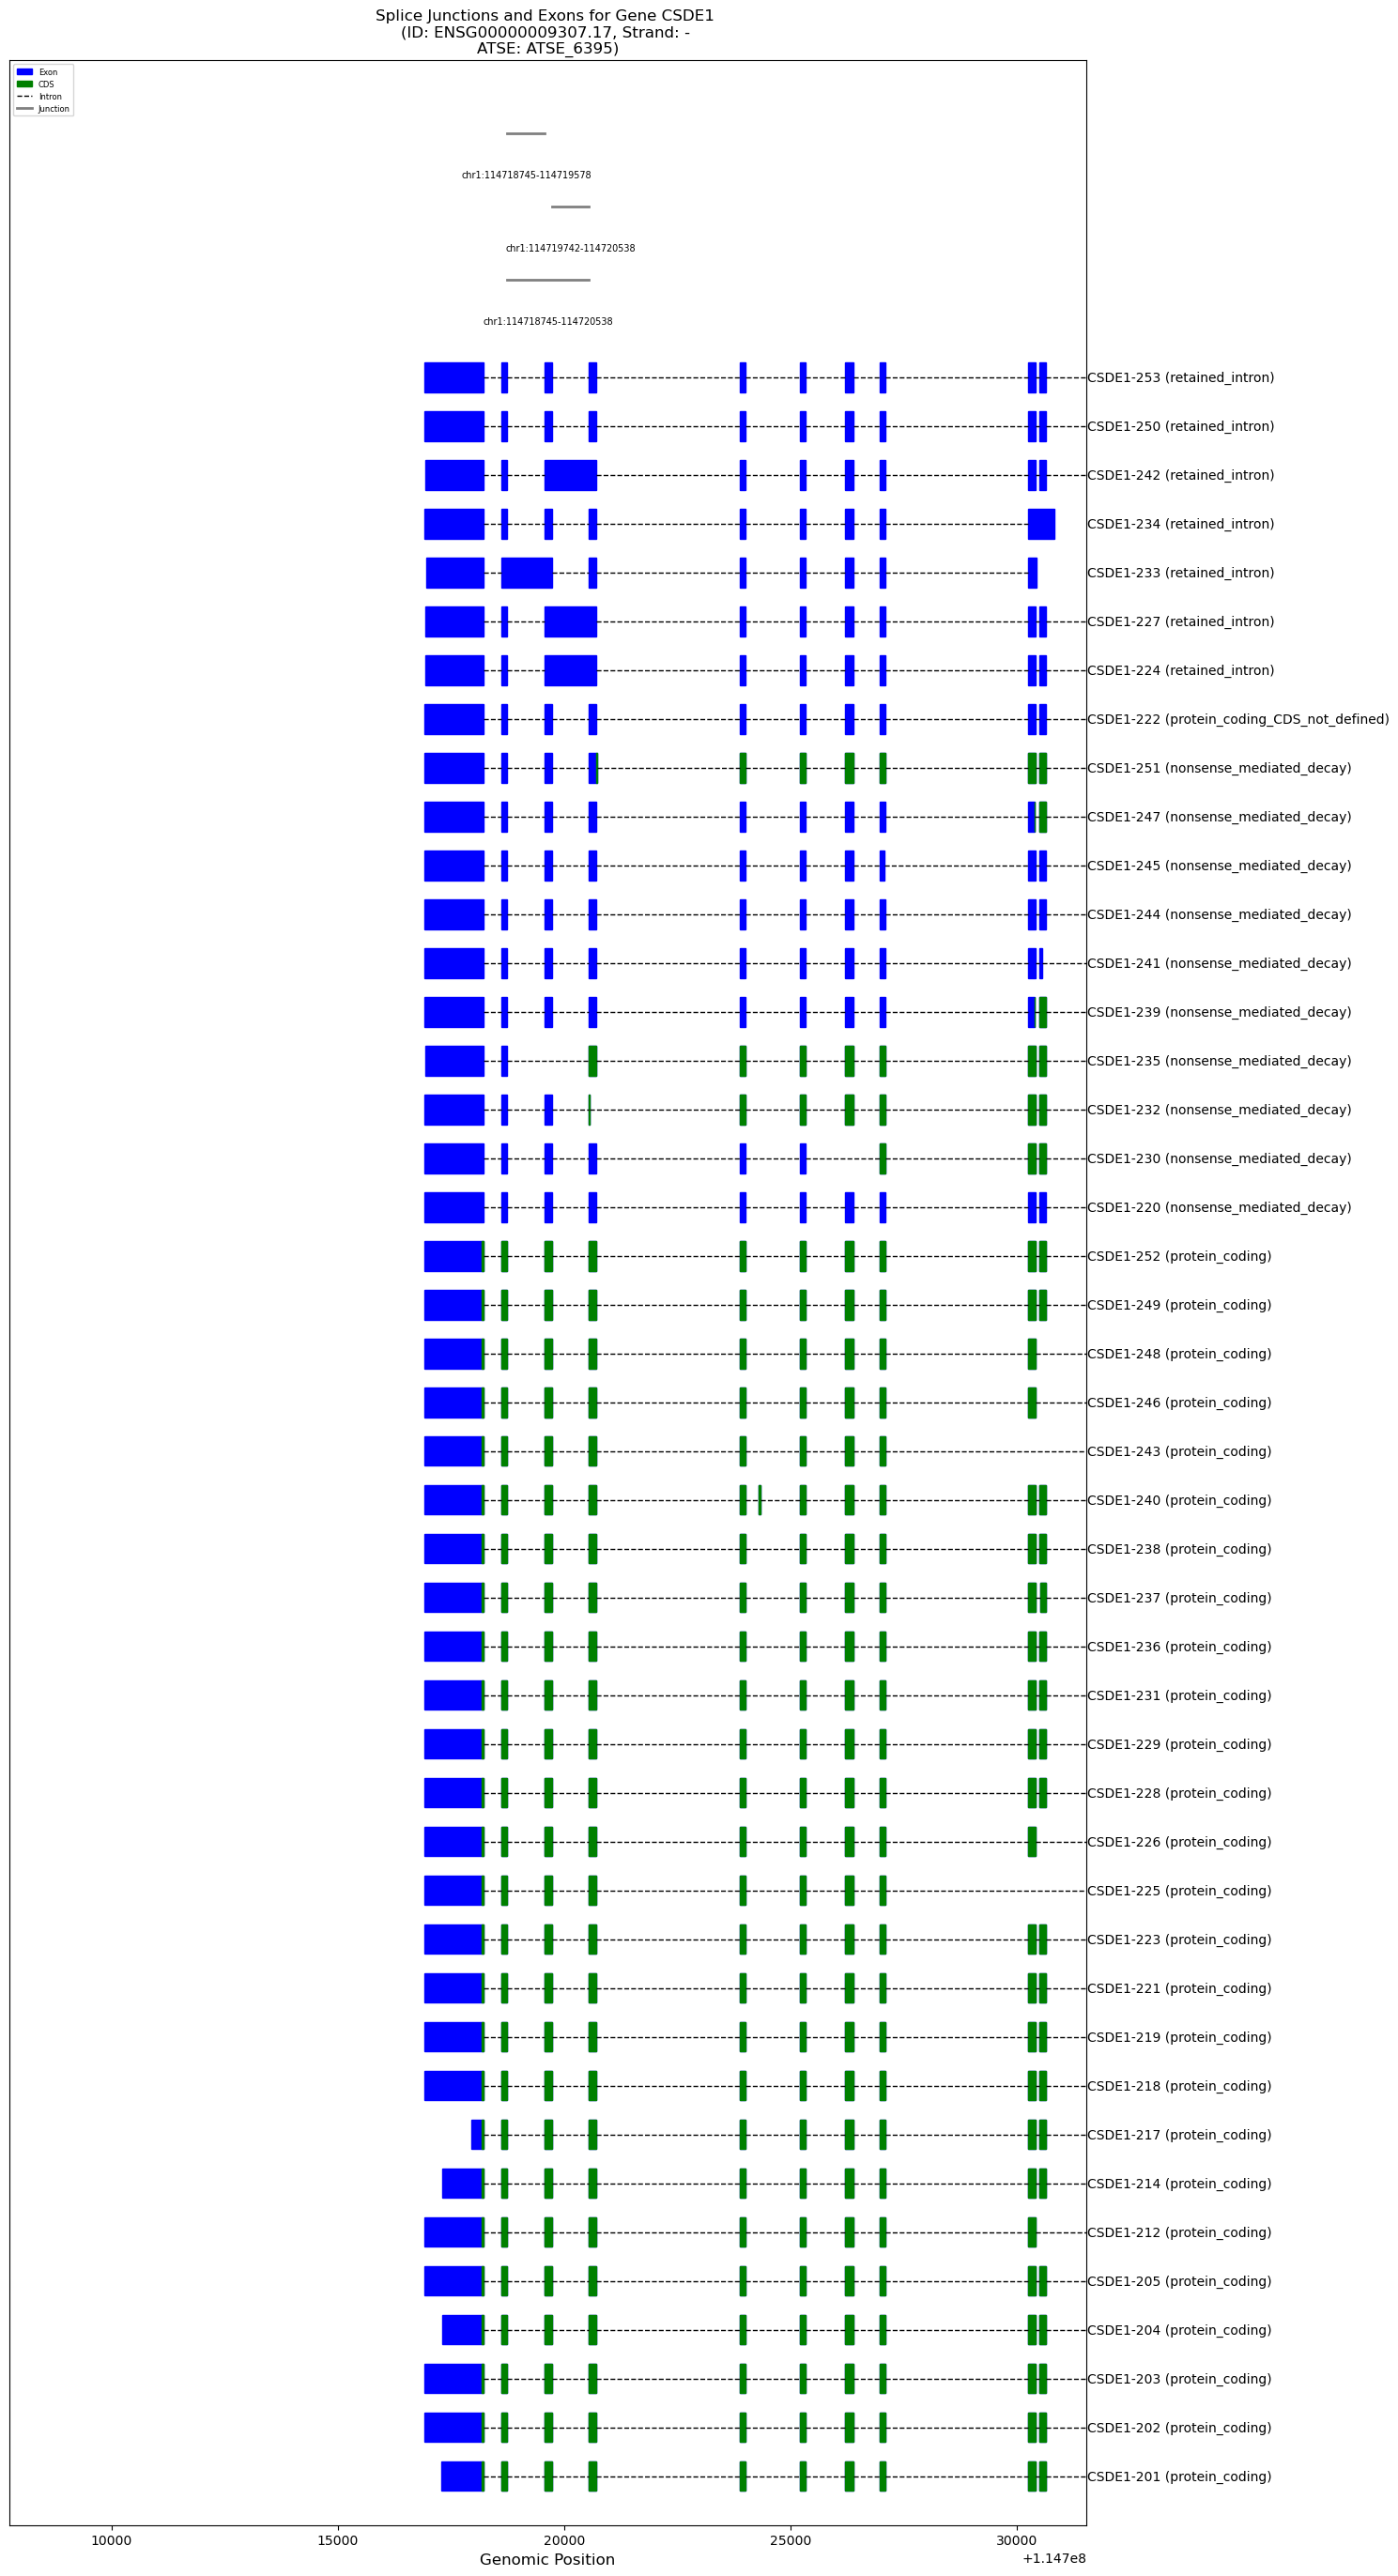

In [16]:
atse_event = "ATSE_6395"
juncs = atses[atses["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)

# Fetch transcript exon coordinates and determine plot boundaries
unique_transcripts = extract_unique_transcripts(juncs)
transcript_data = fetch_transcripts_and_annotations(db_human, unique_transcripts)
print(transcript_data) 

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db_human, atse_event, transcript_data, splice_junctions, region_start-10000, region_end+10000, 
                         base_width=15, trans_height=0.6, show_usage=False, show_junc_lines=False, filename="test.pdf")

In [24]:
adata.obs.tissue.value_counts()

tissue
MTG                16094
V1C                 8052
A1C                 6702
CgG                 6279
Muscle              4887
M1lm                3371
S1ul                3188
Bone_Marrow         3108
Lymph_Node          2942
Lung                2892
M1ul                2864
Spleen              2828
S1lm                2805
Blood               2435
Bladder             2160
Vasculature         2058
Skin                2028
Large_Intestine     1705
Small_Intestine     1679
Salivary_Gland      1604
Tongue              1571
Thymus              1380
Fat                 1216
Liver                812
Trachea              807
Uterus               670
Prostate             624
Eye                  547
Heart                410
Mammary              389
Kidney               352
Name: count, dtype: int64

In [29]:
# Visualize junction usage in CSDE1 ATSEs across tissues... 
CSDE1 = adata[:, adata.var["gene_name"] == "CSDE1"].copy()

# These are your sparse count matrices
from scipy.sparse import csr_matrix
junction_counts = CSDE1.layers["cell_by_junction_matrix"].tocsr()
cluster_counts = CSDE1.layers["cell_by_cluster_matrix"].tocsr()

# Avoid divide-by-zero by only dividing where cluster_counts is non-zero
# Create a copy of junction_counts and perform element-wise division
# Only at positions where junction_counts is non-zero
junc_ratio = junction_counts.copy()
junc_ratio.data = junc_ratio.data / cluster_counts.data

# Store back in AnnData
CSDE1.layers["junc_ratio"] = junc_ratio


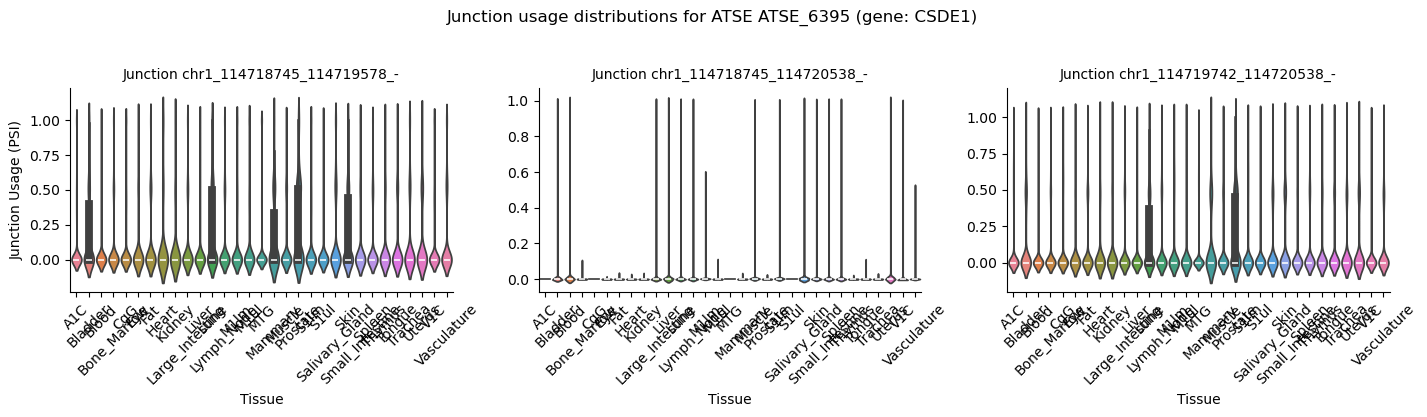

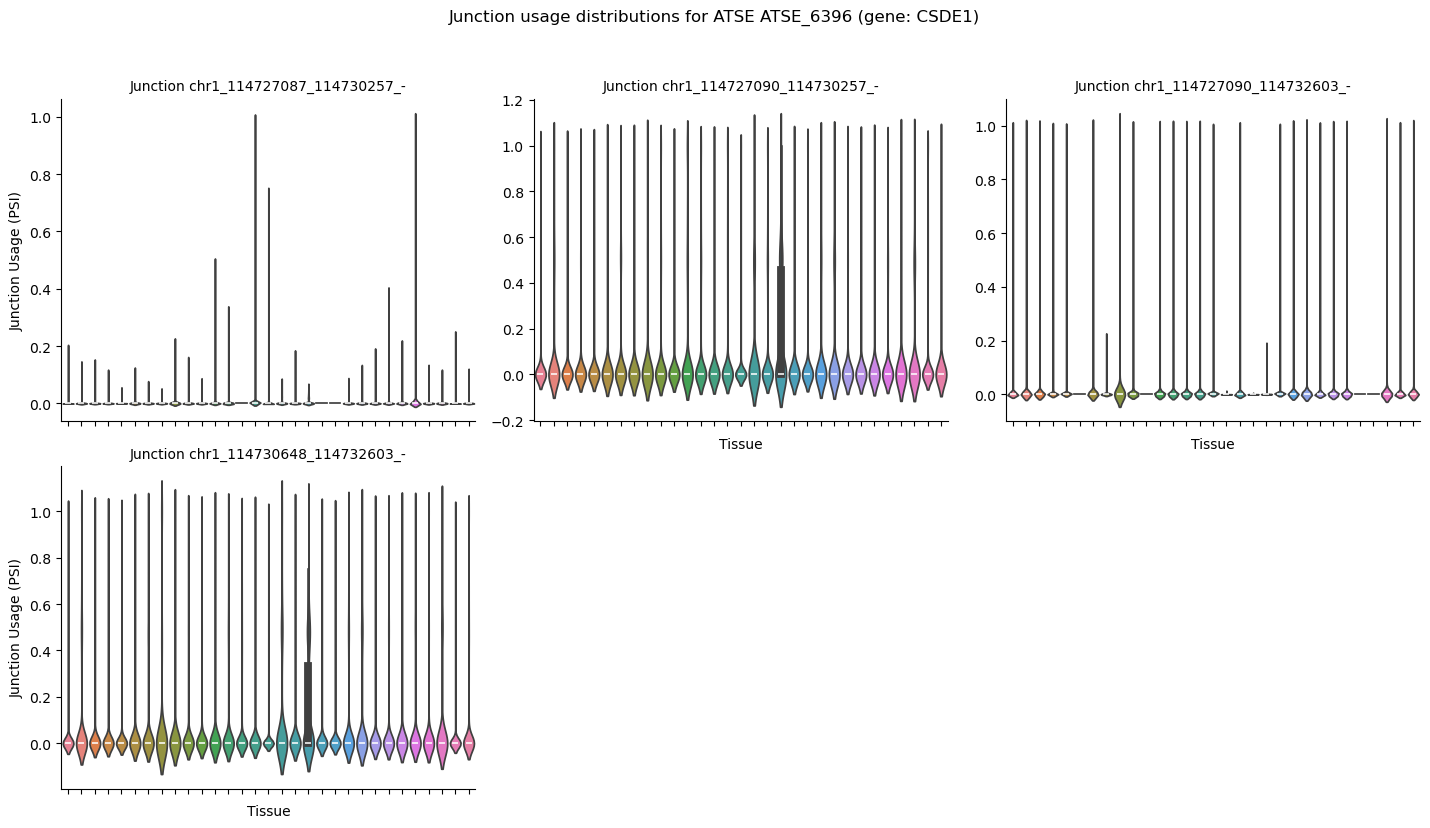

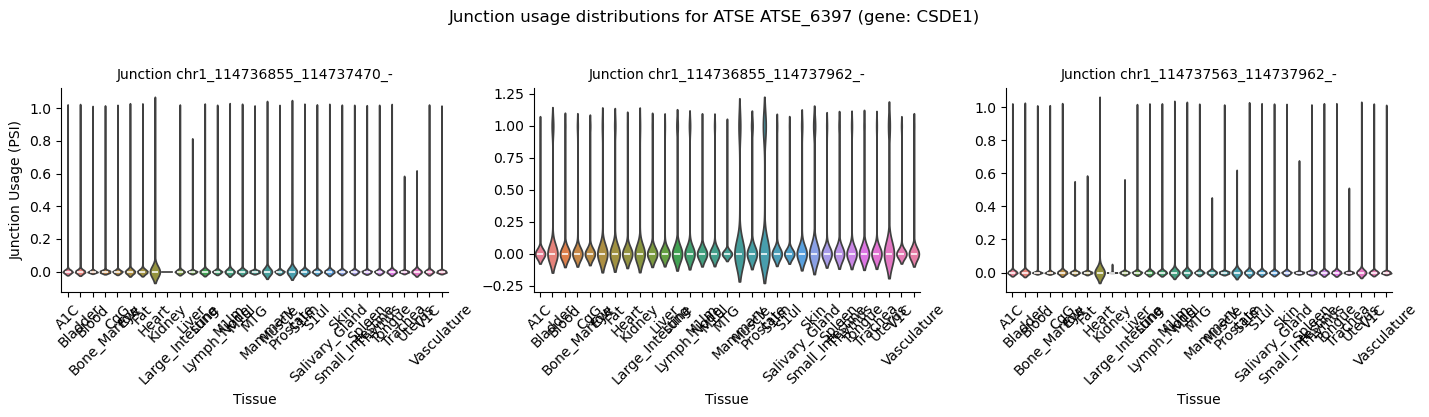

In [38]:
import matplotlib.pyplot as plt

# Loop through unique ATSE events in CSDE1.var
for atse_event in CSDE1.var["event_id"].dropna().unique():
    # Mask for junctions belonging to this ATSE event
    var_mask = CSDE1.var["event_id"] == atse_event
    junc_ids = CSDE1.var["junction_id"][var_mask].values

    if len(junc_ids) == 0:
        continue

    # Convert sparse matrix slice to dense array
    junc_matrix = CSDE1.layers["junc_ratio"][:, var_mask].toarray()  # cells × junctions

    # Construct DataFrame
    junc_df = pd.DataFrame(junc_matrix, columns=junc_ids, index=CSDE1.obs_names)
    junc_df["tissue"] = CSDE1.obs["tissue"].values

    # Melt to long format for plotting
    junc_df_long = junc_df.melt(id_vars="tissue", var_name="junction_id", value_name="PSI")

    # Plot violin plots (distribution of PSI per junction per tissue)
    g = sns.catplot(
        data=junc_df_long,
        x="tissue", y="PSI", hue="tissue",
        col="junction_id", kind="violin", col_wrap=3,
        height=4, aspect=1.2, sharey=False, dodge=False
    )

    g.set_titles("Junction {col_name}")
    g.set_xticklabels(rotation=45)
    g.set_axis_labels("Tissue", "Junction Usage (PSI)")
    g.fig.suptitle(f"Junction usage distributions for ATSE {atse_event} (gene: CSDE1)", y=1.03)
    plt.tight_layout()
    plt.show()


In [37]:
CSDE1.layers["junc_ratio"].data

array([0.37037037, 0.        , 0.62962963, ..., 1.        , 0.        ,
       0.        ])